# Notebook 2 — Content-Based Filtering (Before Merging)

This notebook performs content-based recommendation **without merging** the ratings dataset with the courses dataset.

Models:
- TF-IDF + cosine similarity
- Bag of Words + cosine similarity

Evaluation:
- RMSE
- MAE
- HitRate@10
- Precision@10
- Recall@10
- NDCG@10

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'

sys.path.append(str(PROJECT_ROOT))
import utils_recommender as ur
ur.ensure_dirs(FIGURES_DIR, MODELS_DIR, RESULTS_DIR)

In [2]:
ratings = pd.read_csv(DATA_RAW / 'ratings.csv')
courses = pd.read_csv(DATA_PROCESSED / 'cleaned_courses.csv')
ratings = ratings.rename(columns={'item': 'item'})  # keep same naming
courses = ur.add_num_genres(courses)




In [3]:


content_assets = ur.create_content_similarity(courses)
tfidf_cos_df = content_assets['tfidf_similarity']
bow_cos_df = content_assets['bow_similarity']

print(tfidf_cos_df.shape, bow_cos_df.shape)



(307, 307) (307, 307)


In [4]:
with open(MODELS_DIR / 'tfidf_similarity.pkl', 'wb') as f:
    pickle.dump(tfidf_cos_df, f)
with open(MODELS_DIR / 'bow_similarity.pkl', 'wb') as f:
    pickle.dump(bow_cos_df, f)

print('Similarity matrices saved.')

Similarity matrices saved.


In [5]:
eval_tfidf = ur.evaluate_content_model(tfidf_cos_df, ratings, n_users=300)
eval_bow = ur.evaluate_content_model(bow_cos_df, ratings, n_users=300)

results_cb_before = pd.DataFrame([eval_tfidf, eval_bow], index=['TF-IDF', 'BoW']).round(4)
results_cb_before

,RMSE,MAE,HitRate@10,Precision@10,Recall@10,NDCG@10,Coverage
TF-IDF,0.0196,0.001,0.5033,0.058,0.2958,0.1980,0.4104
BoW,0.0199,0.001,0.4500,0.051,0.2632,0.1851,0.4104


In [6]:
results_cb_before.to_csv(RESULTS_DIR / 'results_content_based_before.csv')
print('Saved:', RESULTS_DIR / 'results_content_based_before.csv')

Saved: C:\Users\habee\Desktop\school\4th_year\term 2\course_recommendation1\XplainaV301\results\results_content_based_before.csv


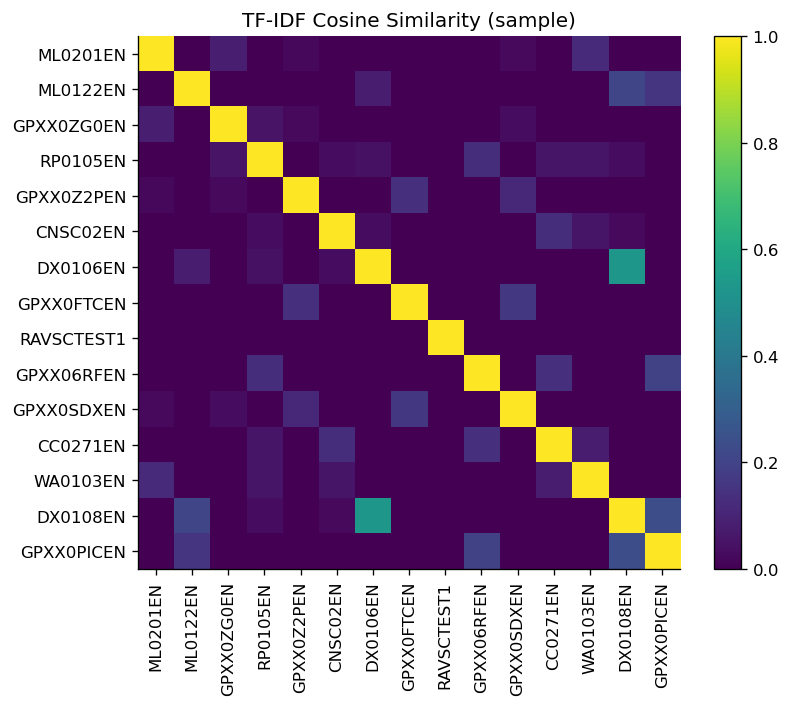

In [7]:
sample_ids = courses['COURSE_ID'].head(15).tolist()
plt.figure(figsize=(7,6))
plt.imshow(tfidf_cos_df.loc[sample_ids, sample_ids], aspect='auto')
plt.title('TF-IDF Cosine Similarity (sample)')
plt.xticks(range(len(sample_ids)), sample_ids, rotation=90)
plt.yticks(range(len(sample_ids)), sample_ids)
plt.colorbar()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'content_tfidf_similarity_sample.png')
plt.show()